# Notebook 06d: Customer Lifetime Value (CLV) Prediction

In this notebook I build a regression pipeline to predict each customer's lifetime value — the total revenue the business can expect from that customer over their relationship. Accurate CLV predictions allow marketing teams to allocate budget proportionally to expected return, prioritise retention efforts, and forecast revenue at a customer-cohort level.

I treat CLV as a supervised regression problem using the pre-engineered features from Notebook 3. I train four models (Ridge Regression, Random Forest, XGBoost, LightGBM) and compare them on RMSE, MAE, R², and MAPE. I also run a SHAP analysis on the best model to explain which features drive predicted value.

## Step-by-step outline

1. Import libraries and configure paths
2. Load the enriched customer dataset
3. Analyse the target variable (Customer_LTV distribution)
4. Prepare the feature matrix — remove leakage columns and non-numeric inputs
5. Stratified train-test split (80/20)
6. Scale features with StandardScaler
7. Train four regression models
8. Evaluate each model and compare performance
9. Feature importance analysis (tree-based models + Ridge coefficients)
10. SHAP explainability on the best model
11. Save all models, scaler, feature list, and metadata

## Step 1: Import Libraries and Configure Paths

I import the four regression algorithms I plan to compare: `Ridge` (linear baseline), `RandomForestRegressor`, `XGBRegressor`, and `LGBMRegressor`. I also import `shap` for post-hoc model explanation — understanding which features drive CLV predictions is as important as the accuracy itself for a business audience.

In [1]:
import pandas as pd
import numpy as np
import warnings
from datetime import datetime
import json
import os

import matplotlib.pyplot as plt
import seaborn as sns

# Regression models: Ridge (linear), RandomForest (bagging), XGBoost and LightGBM (boosting ensembles)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import xgboost as xgb
import lightgbm as lgb

# joblib for persisting sklearn-compatible models; shap for feature attribution
import joblib
import shap

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print(f"Pandas:   {pd.__version__}")
print(f"NumPy:    {np.__version__}")
print(f"XGBoost:  {xgb.__version__}")
print(f"LightGBM: {lgb.__version__}")

Pandas:   2.3.3
NumPy:    1.24.3
XGBoost:  2.0.3
LightGBM: 4.6.0


## Step 2: Configuration and Paths

In [2]:
# Paths to data and artefact directories
DATA_PATH  = '../data/customer_features_enriched.csv'
MODEL_DIR  = '../artifacts/models/'
SCALER_DIR = '../artifacts/scalers/'

# Create output directories if they do not already exist
os.makedirs(MODEL_DIR,  exist_ok=True)
os.makedirs(SCALER_DIR, exist_ok=True)

# Modelling configuration
TEST_SIZE    = 0.2
RANDOM_STATE = 42

print(f"Data path:    {DATA_PATH}")
print(f"Test size:    {TEST_SIZE * 100:.0f}%")
print(f"Random state: {RANDOM_STATE}")

Data path:    ../data/customer_features_enriched.csv
Test size:    20%
Random state: 42


## Step 3: Load Data and Explore the Target Variable

I load the enriched customer dataset and immediately inspect the target (`Customer_LTV`). CLV distributions are almost always right-skewed — a small number of high-value customers dominate the upper tail. Understanding this shape tells me whether I need log-transformation, how to interpret MAPE, and which evaluation metric is most informative.

In [3]:
# Load the enriched customer-level dataset (one row per customer, 54 engineered features)
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape:    {df.shape}")
print(f"Total customers:  {df.shape[0]:,}")
print(f"Total features:   {df.shape[1]:,}")
print(f"Memory usage:     {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

df.head()

Dataset shape:    (86740, 55)
Total customers:  86,740
Total features:   55
Memory usage:     96.69 MB


,Customer_ID,First_Purchase_Date,Last_Purchase_Date,Transaction_Count,Total_Spend,Avg_Order_Value,Std_Order_Value,Frequency,Recency_Days,Customer_Tenure_Days,Transactions_Per_Month,Customer_LTV,Avg_Days_Between_Purchases,Order_Value_CV,Recency_Score,Frequency_Score,Monetary_Score,RFM_Score,Recent_Txn_Count,Recent_Spend,Historical_Txn_Count,Historical_Spend,Purchase_Velocity_Ratio,Spending_Velocity_Ratio,Preferred_Hour,Weekend_Purchase_Pct,Preferred_Day,Preferred_Day_Encoded,Unique_Categories,Favorite_Category,Category_Entropy,Unique_Brands,Avg_Rating,Std_Rating,Min_Rating,Max_Rating,Is_Satisfied_Customer,Preferred_Payment,Payment_Method_Changes,Preferred_Shipping,Shipping_Method_Changes,Pct_Shipped,Pct_Processing,Pct_Cancelled,Avg_Cart_Size,Max_Cart_Size,Std_Cart_Size,Age,Gender,Income,City,State,Country,Customer_Segment,Age_Group
0,10000,2023-05-15,2023-11-19,4,5007.566357,1251.891589,1082.822084,4,102,189,0.63,5007.566357,47.25,0.864949,2.0,3.0,3.0,8.0,0.0,0.0,4.0,5007.566357,0.0,0.0,5,0.75,Sunday,6,4,Clothing,1.386294,4,3.5,1.290994,2.0,5.0,0,Cash,4,Express,2,0.0,0.0,0,5.25,7.0,1.707825,26.0,Male,Medium,Phoenix,NORTH CAROLINA,Usa,Regular,25-34
1,10001,2023-03-15,2023-11-17,5,8136.462824,1627.292565,1348.648304,5,104,248,0.60,8136.462824,49.60,0.828768,2.0,4.0,5.0,11.0,0.0,0.0,5.0,8136.462824,0.0,0.0,9,0.40,Saturday,5,4,Grocery,1.332179,4,3.6,1.673320,1.0,5.0,0,Cash,4,Express,2,0.4,0.2,0,4.80,8.0,2.167948,19.0,Male,Medium,Portsmouth,ENGLAND,Uk,Regular,18-24
2,10002,2023-04-20,2023-11-27,5,4104.013951,820.802790,1131.996776,5,94,222,0.68,4104.013951,44.40,1.379134,3.0,4.0,3.0,10.0,0.0,0.0,5.0,4104.013951,0.0,0.0,3,0.40,Sunday,6,3,Books,1.054920,3,3.2,1.303840,1.0,4.0,0,Credit Card,3,Express,2,0.4,0.0,0,3.40,7.0,2.880972,20.0,Male,Low,Gold Coast,NEW SOUTH WALES,Australia,Premium,18-24
3,10003,2023-05-02,2023-07-17,2,2340.496447,1170.248223,1018.923407,2,227,77,0.78,2340.496447,38.50,0.870690,1.0,1.0,2.0,4.0,0.0,0.0,2.0,2340.496447,0.0,0.0,3,0.00,Monday,0,2,Clothing,0.693147,2,2.5,0.707107,2.0,3.0,0,Debit Card,1,Express,2,0.0,0.0,0,8.50,9.0,0.707107,26.0,Male,High,San Francisco,MAINE,Usa,Regular,25-34
4,10004,2023-10-07,2024-01-30,2,2356.516683,1178.258341,513.160623,2,30,116,0.52,2356.516683,58.00,0.435525,4.0,1.0,2.0,7.0,0.0,0.0,2.0,2356.516683,0.0,0.0,14,0.50,Saturday,5,2,Grocery,0.693147,2,3.0,2.828427,1.0,5.0,0,Cash,2,Express,2,0.0,0.5,0,5.00,6.0,1.414214,23.0,Male,High,Boston,GEORGIA,Usa,Regular,18-24


In [4]:
# Quick overview of column data types so I know which columns need encoding or dropping
print("Data type counts:")
print(df.dtypes.value_counts())

Data type counts:
float64    29
int64      13
object     13
Name: count, dtype: int64


In [5]:
# Check for missing values — the enriched dataset should be clean, but I verify here
# before any modelling so a schema change in upstream notebooks does not cause silent bugs
missing_summary = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percent': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Missing_Count', ascending=False)

problematic = missing_summary[missing_summary['Missing_Count'] > 0]
if len(problematic) > 0:
    print("Columns with missing values:")
    print(problematic)
else:
    print("No missing values detected")

No missing values detected


## Step 4: Target Variable Analysis

I plot the raw distribution, a box plot, and a log-transformed histogram. The log view is useful because tree-based models handle log-normal targets well without explicit transformation, but knowing the distribution shape helps me decide whether to apply `log1p` to the target.

In [6]:
# Summary statistics for the CLV target
# Skewness > 1 indicates a right-heavy tail that can inflate RMSE; I check for it here
print("Customer LTV — descriptive statistics:")
print(df['Customer_LTV'].describe().round(2))
print(f"\nSkewness:  {df['Customer_LTV'].skew():.2f}")
print(f"Kurtosis:  {df['Customer_LTV'].kurtosis():.2f}")

Customer LTV — descriptive statistics:
count    86740.00
mean      4746.48
std       3201.93
min         10.30
25%       2291.47
50%       4221.49
75%       6591.75
max      29241.78
Name: Customer_LTV, dtype: float64

Skewness:  0.96
Kurtosis:  1.14


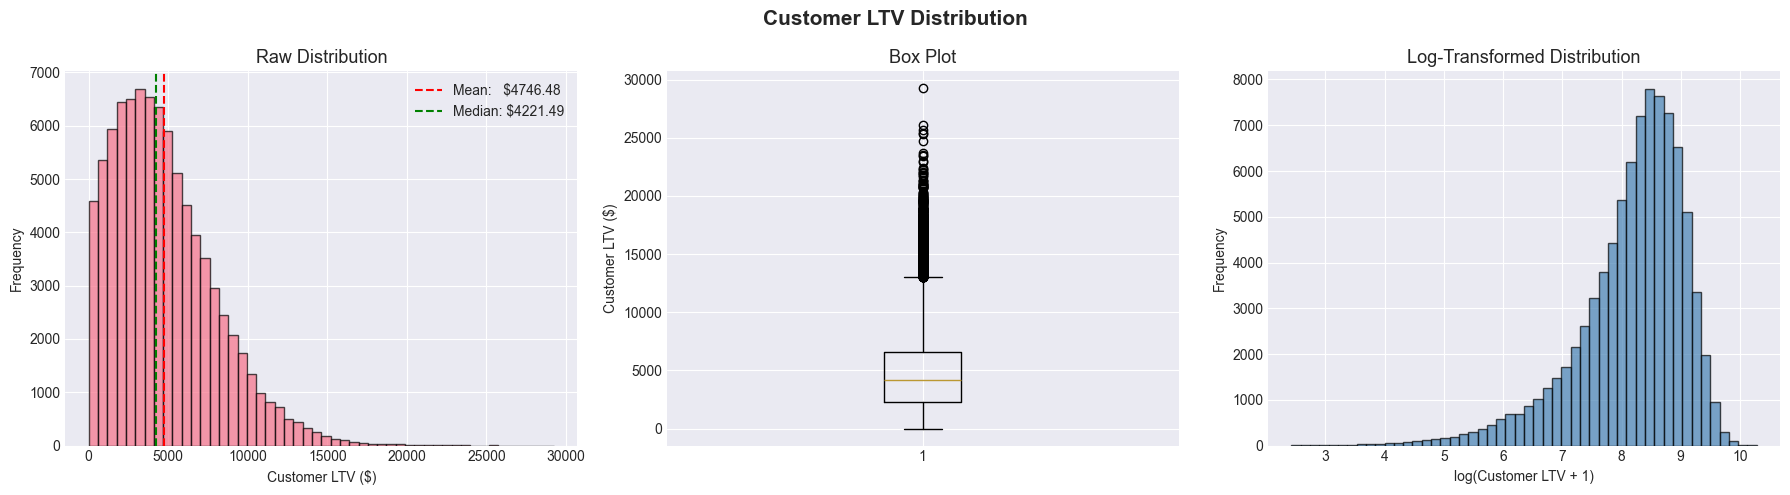

In [7]:
# Visualise the CLV distribution from three angles:
#   left  — raw histogram shows the skew and any obvious outlier spikes
#   centre — box plot shows median, IQR, and whisker extent
#   right  — log-transformed histogram shows whether the distribution normalises on a log scale
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Customer LTV Distribution', fontsize=15, fontweight='bold')

# Raw histogram with mean and median reference lines
axes[0].hist(df['Customer_LTV'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Raw Distribution', fontsize=13)
axes[0].set_xlabel('Customer LTV ($)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['Customer_LTV'].mean(),   color='red',   linestyle='--', label=f"Mean:   ${df['Customer_LTV'].mean():.2f}")
axes[0].axvline(df['Customer_LTV'].median(), color='green', linestyle='--', label=f"Median: ${df['Customer_LTV'].median():.2f}")
axes[0].legend()

# Box plot to visualise outlier extent
axes[1].boxplot(df['Customer_LTV'], vert=True)
axes[1].set_title('Box Plot', fontsize=13)
axes[1].set_ylabel('Customer LTV ($)')

# Log1p-transformed histogram — if this is bell-shaped the target is log-normal
axes[2].hist(np.log1p(df['Customer_LTV']), bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[2].set_title('Log-Transformed Distribution', fontsize=13)
axes[2].set_xlabel('log(Customer LTV + 1)')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../reports/clv_target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 5: Feature Preparation and Leakage Removal

The most important step before any CLV model is removing data leakage. `Customer_LTV` is defined as total customer spend, so any spend-derived column (`Total_Spend`, `Historical_Spend`, `Recent_Spend`, `Monetary_Score`) is a direct or near-direct copy of the target. If I left these in, the model would achieve near-perfect R² on training data but would be completely useless in production — it would need the answer to predict the answer. I also drop identifier columns, date strings, and other non-numeric text columns.

In [8]:
# Columns that are the same thing as Customer_LTV or directly derived from it —
# keeping any of these would give the model the answer before it has even trained
leakage_cols = [
    'Total_Spend',       # Customer_LTV IS total spend — perfect leakage
    'Historical_Spend',  # a subset of total spend — direct leakage
    'Recent_Spend',      # a subset of total spend — direct leakage
    'Monetary_Score',    # RFM score derived purely from spend — near-perfect leakage
]

# Identifier and target columns — never used as features
id_target_cols = ['Customer_ID', 'Customer_LTV']

# Date columns produced by strftime are strings; they would need cyclical encoding
# and are not worth the extra complexity here
date_cols = [c for c in df.columns if any(kw in c.lower() for kw in ['date', 'time'])]

# Remaining object columns (e.g. city, product category aggregates) are text and
# would need OHE; I drop them to keep the pipeline fully numeric
categorical_text_cols = df.select_dtypes(include=['object']).columns.tolist()

all_exclude = set(id_target_cols + leakage_cols + date_cols + categorical_text_cols)

feature_cols = [c for c in df.columns if c not in all_exclude]

print(f"Leakage columns removed:       {leakage_cols}")
print(f"Date columns removed:          {date_cols}")
print(f"Text columns removed:          {categorical_text_cols}")
print(f"\nFinal feature count:           {len(feature_cols)}")
print(f"First 10 features:             {feature_cols[:10]}")

Leakage columns removed:       ['Total_Spend', 'Historical_Spend', 'Recent_Spend', 'Monetary_Score']
Date columns removed:          ['First_Purchase_Date', 'Last_Purchase_Date']
Text columns removed:          ['First_Purchase_Date', 'Last_Purchase_Date', 'Preferred_Day', 'Favorite_Category', 'Preferred_Payment', 'Preferred_Shipping', 'Gender', 'Income', 'City', 'State', 'Country', 'Customer_Segment', 'Age_Group']

Final feature count:           36
First 10 features:             ['Transaction_Count', 'Avg_Order_Value', 'Std_Order_Value', 'Frequency', 'Recency_Days', 'Customer_Tenure_Days', 'Transactions_Per_Month', 'Avg_Days_Between_Purchases', 'Order_Value_CV', 'Recency_Score']


In [9]:
# Build the feature matrix X and target vector y
X = df[feature_cols].copy()
y = df['Customer_LTV'].copy()

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape:  {y.shape}")

Feature matrix shape: (86740, 36)
Target vector shape:  (86740,)


In [10]:
# Final check: confirm all remaining features are numeric.
# Non-numeric columns here would cause sklearn models to raise a ValueError at fit time.
non_numeric = X.select_dtypes(exclude=['number']).columns.tolist()
if non_numeric:
    print(f"WARNING — non-numeric columns still present: {non_numeric}")
else:
    print("All feature columns are numeric — safe to proceed")

All feature columns are numeric — safe to proceed


## Step 6: Stratified Train-Test Split

A plain random split of a skewed target risks concentrating most high-CLV customers in one partition, making train and test distributions look very different. I bin the target into deciles and use stratified splitting so that each decile is proportionally represented in both train and test. This gives a fairer evaluation and more stable metrics.

In [11]:
# Bin the target into 10 equal-frequency buckets so the stratified splitter
# can keep the CLV distribution balanced across train and test sets
y_bins = pd.qcut(y, q=10, labels=False, duplicates='drop')

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_bins
)

print(f"Training set:  {X_train.shape[0]:,} customers  ({(1 - TEST_SIZE)*100:.0f}%)")
print(f"Test set:      {X_test.shape[0]:,} customers  ({TEST_SIZE*100:.0f}%)")
print(f"Features:      {X_train.shape[1]}")

# Verify that mean CLV is similar in both splits — if they differ significantly the
# stratification has not fully balanced the distribution
print(f"\nTarget distribution check:")
print(f"  Train — mean: ${y_train.mean():.2f},  median: ${y_train.median():.2f},  std: ${y_train.std():.2f}")
print(f"  Test  — mean: ${y_test.mean():.2f},  median: ${y_test.median():.2f},  std: ${y_test.std():.2f}")

Training set:  69,392 customers  (80%)
Test set:      17,348 customers  (20%)
Features:      36

Target distribution check:
  Train — mean: $4744.70,  median: $4221.49,  std: $3199.80
  Test  — mean: $4753.58,  median: $4221.57,  std: $3210.49


## Step 7: Feature Scaling

Ridge Regression is sensitive to feature scale because it applies equal L2 penalty to all coefficients regardless of magnitude. I fit the scaler only on training data and apply the same learned parameters to the test set — fitting on the full dataset would leak test-set statistics into the training process.

In [12]:
# Fit the scaler on training data only — never on x_test, to prevent leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Wrap back into DataFrames so feature names are preserved for SHAP and importance plots
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test.columns,  index=X_test.index)

print(f"Scaled training shape: {X_train_scaled.shape}")
print(f"Scaled test shape:     {X_test_scaled.shape}")

Scaled training shape: (69392, 36)
Scaled test shape:     (17348, 36)


## Step 8: Train Four Regression Models

I train four models that represent a spectrum from interpretable to complex:

1. **Ridge Regression** — linear baseline with L2 regularisation; tells me whether the relationship between features and CLV is roughly linear
2. **Random Forest** — bagged ensemble of decision trees; robust to outliers and handles non-linear interactions automatically
3. **XGBoost** — gradient boosting; often the strongest performer on tabular data; I use a standard configuration without extensive hyperparameter tuning
4. **LightGBM** — leaf-wise gradient boosting; faster than XGBoost on larger datasets; comparable accuracy

### Model 1: Ridge Regression

In [13]:
# Ridge regularises by adding α * sum(β²) to the loss function.
# alpha=1.0 is a mild penalty — I start here as a baseline; if it overfits I increase α.
ridge_model = Ridge(alpha=1.0, random_state=RANDOM_STATE)
ridge_model.fit(X_train_scaled, y_train)

ridge_train_pred = ridge_model.predict(X_train_scaled)
ridge_test_pred  = ridge_model.predict(X_test_scaled)
print("Ridge Regression trained")

Ridge Regression trained


### Model 2: Random Forest

In [14]:
# Random Forest with controlled depth to prevent overfitting.
# min_samples_split=10 and min_samples_leaf=4 require a minimum amount of data
# in each decision node and leaf, which regularises the trees and reduces variance.
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)

rf_train_pred = rf_model.predict(X_train_scaled)
rf_test_pred  = rf_model.predict(X_test_scaled)
print("Random Forest trained")

Random Forest trained


### Model 3: XGBoost

In [15]:
# XGBoost gradient boosting with row and column subsampling.
# subsample=0.8 and colsample_bytree=0.8 randomly sample 80% of rows and features
# per tree, which acts as a regulariser and reduces the correlation between trees.
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0
)
xgb_model.fit(X_train_scaled, y_train)

xgb_train_pred = xgb_model.predict(X_train_scaled)
xgb_test_pred  = xgb_model.predict(X_test_scaled)
print("XGBoost trained")

XGBoost trained


### Model 4: LightGBM

In [16]:
# LightGBM uses leaf-wise tree growth instead of depth-wise, which makes it faster
# on larger datasets. verbose=-1 suppresses the training log output entirely.
lgb_model = lgb.LGBMRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)
lgb_model.fit(X_train_scaled, y_train)

lgb_train_pred = lgb_model.predict(X_train_scaled)
lgb_test_pred  = lgb_model.predict(X_test_scaled)
print("LightGBM trained")

LightGBM trained


## Step 9: Model Evaluation

I evaluate every model on four metrics. Each tells me something different:
- **RMSE** — penalises large errors heavily; important because high-CLV customer mispredictions are costly
- **MAE** — average absolute error in dollar terms; easier for stakeholders to interpret
- **R²** — proportion of CLV variance explained by the model
- **MAPE** — percentage error; useful for comparing across different CLV scales

In [17]:
def calculate_mape(y_true, y_pred):
    """Compute MAPE while guarding against division by zero near-zero targets."""
    epsilon = 1e-10
    return float(np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + epsilon))) * 100)


def evaluate_model(y_true, y_pred, dataset_name=''):
    """Return a dict of RMSE, MAE, R2, and MAPE for one set of predictions."""
    return {
        'Dataset': dataset_name,
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'MAE':  float(mean_absolute_error(y_true, y_pred)),
        'R2':   float(r2_score(y_true, y_pred)),
        'MAPE': calculate_mape(y_true, y_pred)
    }

### Evaluation: Ridge Regression

In [18]:
# I compare train vs test metrics side by side to detect overfitting:
# a large gap between train R2 and test R2 means the model is memorising training data.
ridge_train_metrics = evaluate_model(y_train, ridge_train_pred, 'Train')
ridge_test_metrics  = evaluate_model(y_test,  ridge_test_pred,  'Test')

ridge_results = pd.DataFrame([ridge_train_metrics, ridge_test_metrics])
print("Ridge Regression performance:")
print(ridge_results.to_string(index=False))

Ridge Regression performance:
Dataset       RMSE        MAE      R2      MAPE
  Train 843.550476 567.311201 0.93050 28.607483
   Test 844.276778 566.025970 0.93084 27.804880


### Evaluation: Random Forest

In [19]:
rf_train_metrics = evaluate_model(y_train, rf_train_pred, 'Train')
rf_test_metrics  = evaluate_model(y_test,  rf_test_pred,  'Test')

rf_results = pd.DataFrame([rf_train_metrics, rf_test_metrics])
print("Random Forest performance:")
print(rf_results.to_string(index=False))

Random Forest performance:
Dataset      RMSE      MAE       R2     MAPE
  Train 51.119735 3.945759 0.999745 0.068781
   Test 63.365058 6.016555 0.999610 0.105869


### Evaluation: XGBoost

In [20]:
xgb_train_metrics = evaluate_model(y_train, xgb_train_pred, 'Train')
xgb_test_metrics  = evaluate_model(y_test,  xgb_test_pred,  'Test')

xgb_results = pd.DataFrame([xgb_train_metrics, xgb_test_metrics])
print("XGBoost performance:")
print(xgb_results.to_string(index=False))

XGBoost performance:
Dataset      RMSE       MAE       R2     MAPE
  Train 85.673961 62.190087 0.999283 2.197930
   Test 96.754677 66.468680 0.999092 2.314217


### Evaluation: LightGBM

In [21]:
lgb_train_metrics = evaluate_model(y_train, lgb_train_pred, 'Train')
lgb_test_metrics  = evaluate_model(y_test,  lgb_test_pred,  'Test')

lgb_results = pd.DataFrame([lgb_train_metrics, lgb_test_metrics])
print("LightGBM performance:")
print(lgb_results.to_string(index=False))

LightGBM performance:
Dataset       RMSE       MAE       R2     MAPE
  Train 126.736826 90.518324 0.998431 3.372104
   Test 133.676366 94.274635 0.998266 3.477619


## Step 10: Model Comparison

I compile all four test-set results into one table sorted by R² and then produce two comparison visualisations: a bar chart of each metric and a predicted-vs-actual scatter for each model. The scatter shows not just the R² headline but also whether errors are systematic (upward or downward bias) or random.

In [22]:
# Build a single comparison table sorted by test R² (higher = better)
comparison_df = pd.DataFrame([
    {'Model': 'Ridge Regression', **{k: v for k, v in ridge_test_metrics.items() if k != 'Dataset'}},
    {'Model': 'Random Forest',    **{k: v for k, v in rf_test_metrics.items()    if k != 'Dataset'}},
    {'Model': 'XGBoost',          **{k: v for k, v in xgb_test_metrics.items()   if k != 'Dataset'}},
    {'Model': 'LightGBM',         **{k: v for k, v in lgb_test_metrics.items()   if k != 'Dataset'}},
])
comparison_df = comparison_df.sort_values('R2', ascending=False).reset_index(drop=True)

print("Model comparison on test set (sorted by R2):")
print(comparison_df.to_string(index=False))

# Identify the best model by R2 for SHAP analysis and deployment
best_model_name = comparison_df.iloc[0]['Model']
print(f"\nBest model: {best_model_name}  (R2 = {comparison_df.iloc[0]['R2']:.4f})")

Model comparison on test set (sorted by R2):
           Model       RMSE        MAE       R2      MAPE
   Random Forest  63.365058   6.016555 0.999610  0.105869
         XGBoost  96.754677  66.468680 0.999092  2.314217
        LightGBM 133.676366  94.274635 0.998266  3.477619
Ridge Regression 844.276778 566.025970 0.930840 27.804880

Best model: Random Forest  (R2 = 0.9996)


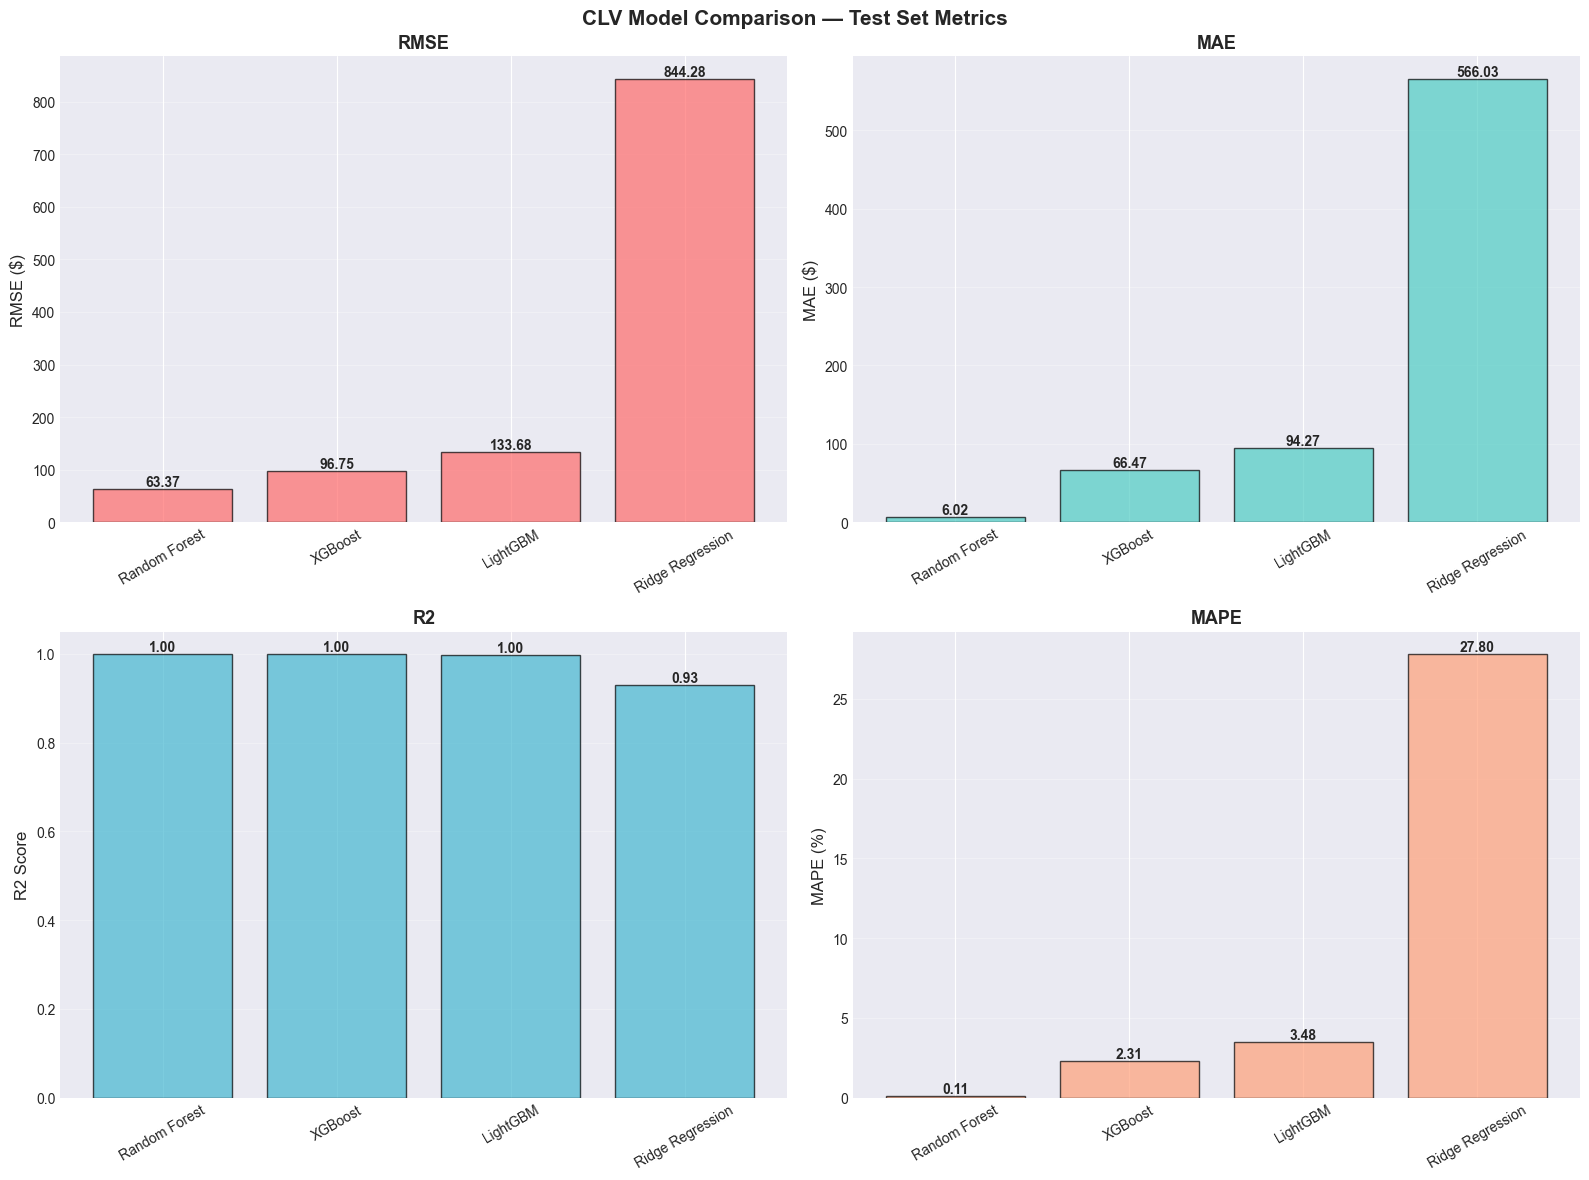

In [23]:
# Bar chart comparison for all four metrics.
# I place RMSE and MAE (dollar errors) and MAPE (percentage error) on the same plot as R2
# so the reader can judge both accuracy magnitude and fit quality in one view.
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('CLV Model Comparison — Test Set Metrics', fontsize=15, fontweight='bold')

metrics_to_plot = [('RMSE', 'RMSE ($)'), ('MAE', 'MAE ($)'), ('R2', 'R2 Score'), ('MAPE', 'MAPE (%)')]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

for idx, ((metric, ylabel), color) in enumerate(zip(metrics_to_plot, colors)):
    ax = axes[idx // 2, idx % 2]
    bars = ax.bar(comparison_df['Model'], comparison_df[metric], color=color, alpha=0.7, edgecolor='black')

    # Label each bar with the numeric value
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h, f'{h:.2f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12)
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/clv_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

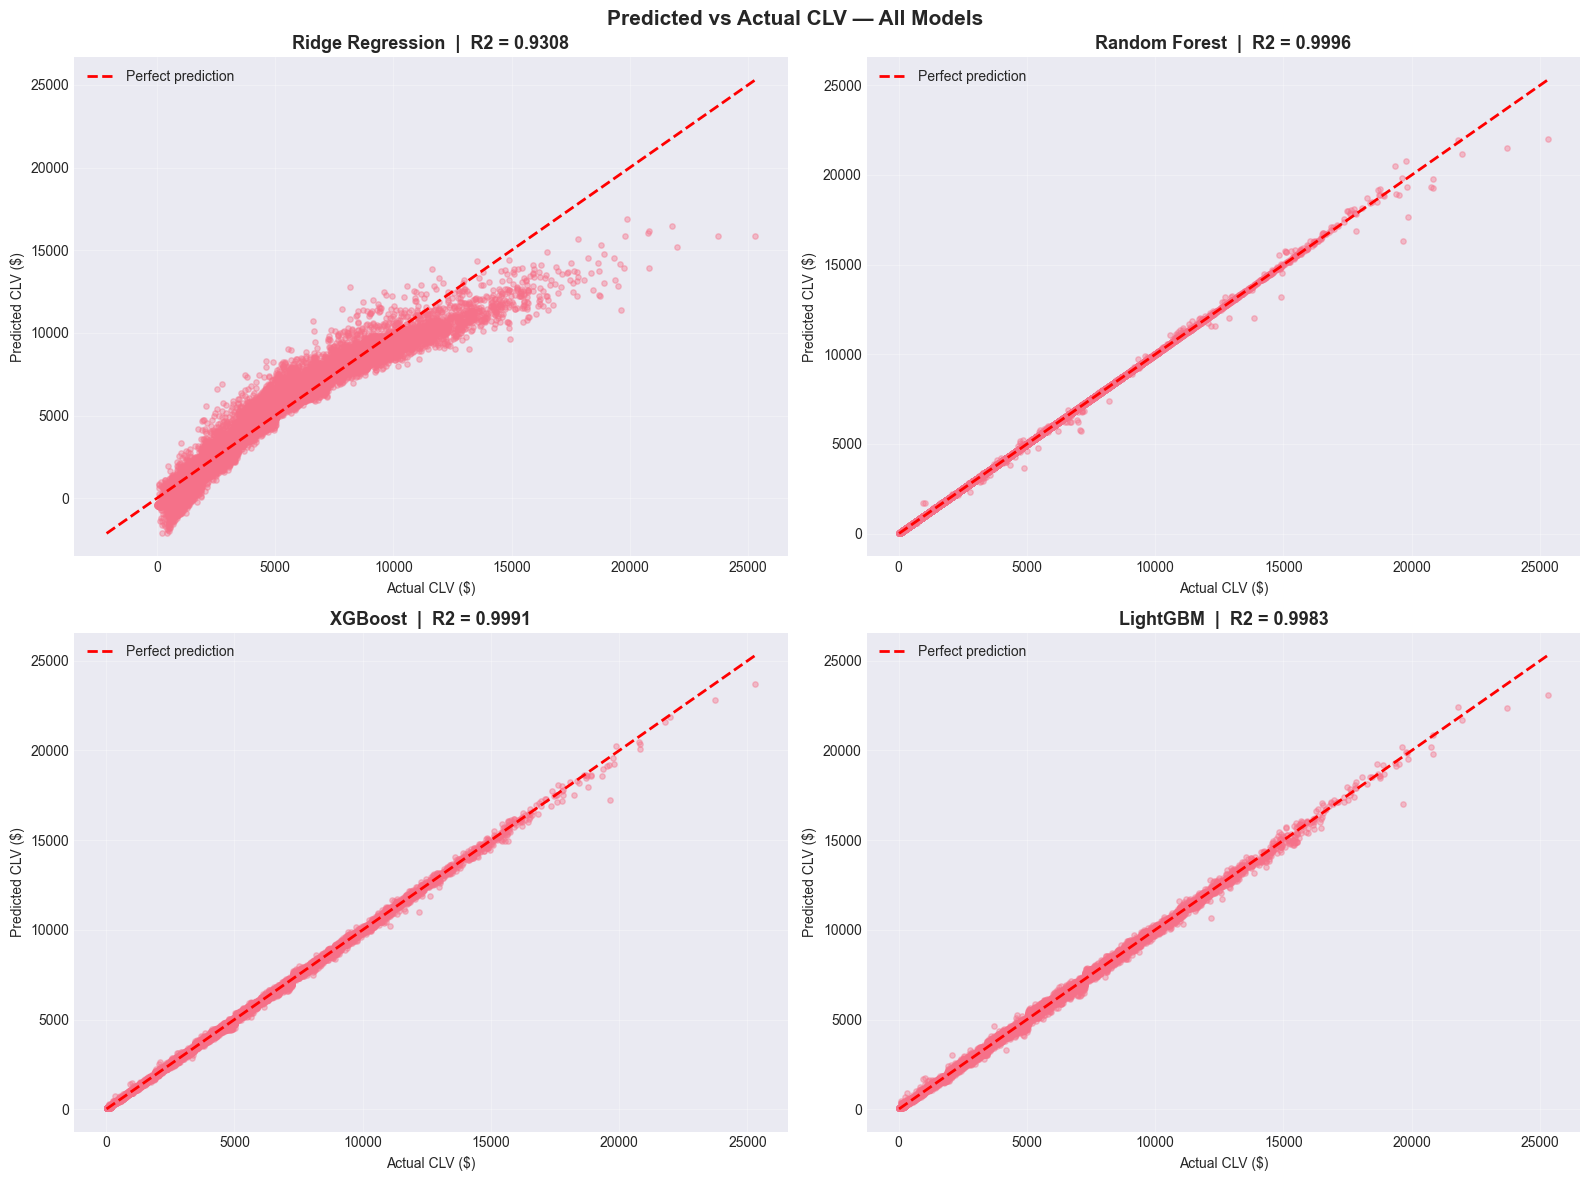

In [24]:
# Predicted vs Actual scatter for all four models.
# Points should cluster tightly around the red dashed line (perfect prediction).
# A fan-shaped scatter (wider gap at high CLV) would indicate heteroscedasticity —
# the model struggles most with the highest-value customers.
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Predicted vs Actual CLV — All Models', fontsize=15, fontweight='bold')

models_data = [
    ('Ridge Regression', ridge_test_pred),
    ('Random Forest',    rf_test_pred),
    ('XGBoost',          xgb_test_pred),
    ('LightGBM',         lgb_test_pred),
]

for idx, (model_name, predictions) in enumerate(models_data):
    ax = axes[idx // 2, idx % 2]
    ax.scatter(y_test, predictions, alpha=0.4, s=15)

    lo = min(y_test.min(), predictions.min())
    hi = max(y_test.max(), predictions.max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=2, label='Perfect prediction')

    r2 = r2_score(y_test, predictions)
    ax.set_title(f'{model_name}  |  R2 = {r2:.4f}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Actual CLV ($)')
    ax.set_ylabel('Predicted CLV ($)')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/clv_predicted_vs_actual.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 11: Feature Importance Analysis

I plot the top 15 feature importances for the three tree-based models side by side. For Ridge Regression, I plot the raw coefficient magnitudes. Comparing which features appear in the top 15 across models shows which inputs are robustly predictive of CLV regardless of the algorithm used.

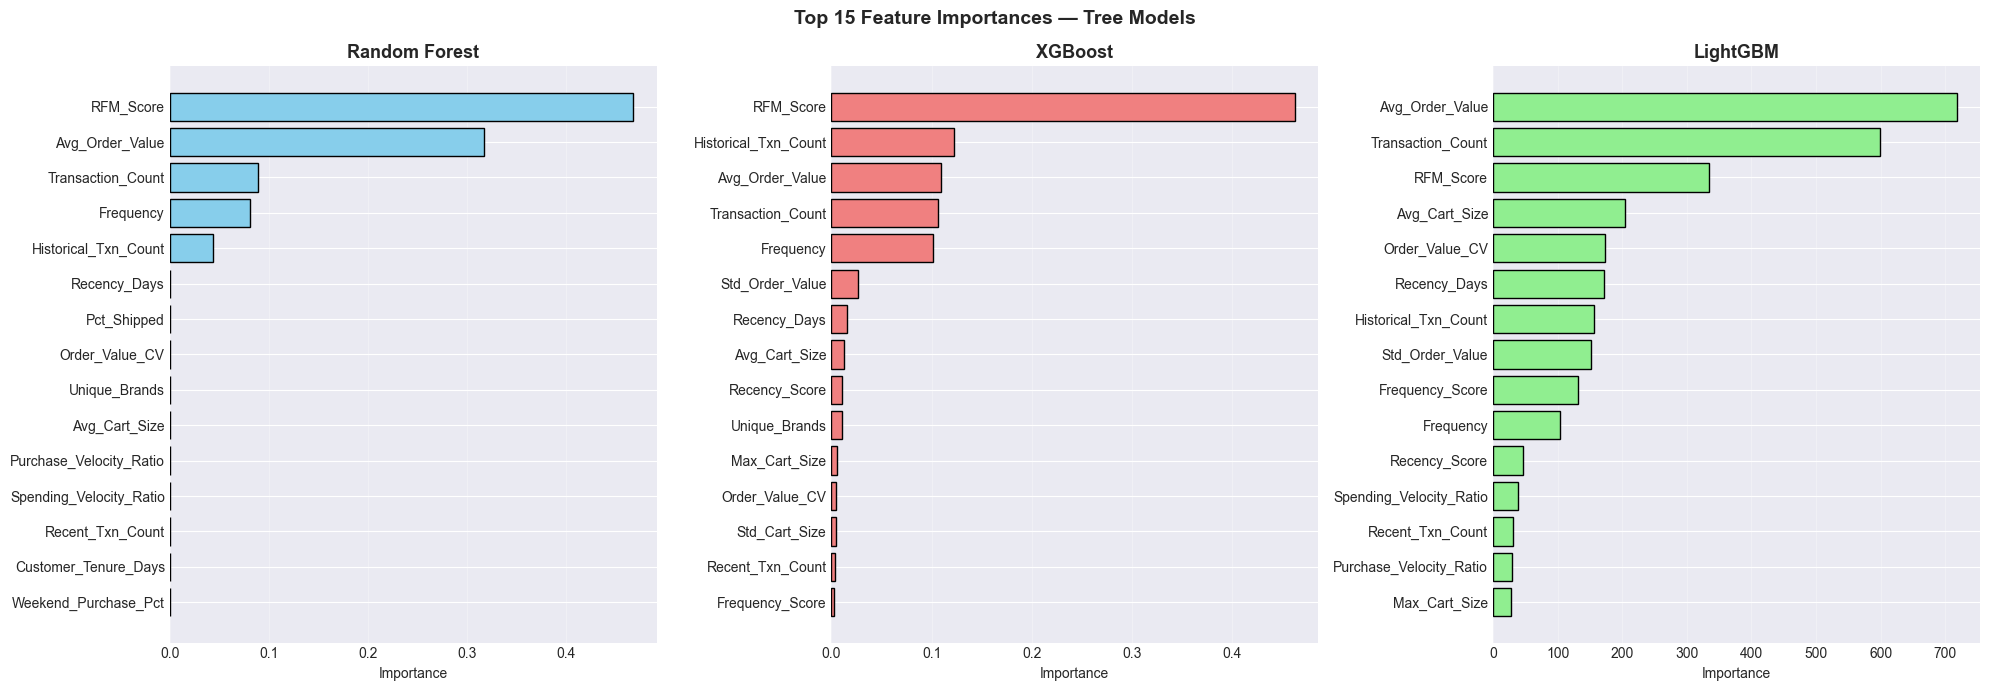

In [25]:
# Feature importance for the three tree-based models.
# Random Forest uses impurity-based importance (mean decrease in impurity).
# XGBoost and LightGBM also use impurity-based importance by default.
# All three are normalised differently so I compare rank order rather than exact values.
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Top 15 Feature Importances — Tree Models', fontsize=14, fontweight='bold')

for ax, model, name, color in [
    (axes[0], rf_model,  'Random Forest', 'skyblue'),
    (axes[1], xgb_model, 'XGBoost',       'lightcoral'),
    (axes[2], lgb_model, 'LightGBM',      'lightgreen'),
]:
    imp_df = pd.DataFrame({
        'Feature':    X_train.columns,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=False).head(15)

    ax.barh(imp_df['Feature'], imp_df['Importance'], color=color, edgecolor='black')
    ax.set_xlabel('Importance')
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/clv_feature_importance_trees.png', dpi=300, bbox_inches='tight')
plt.show()

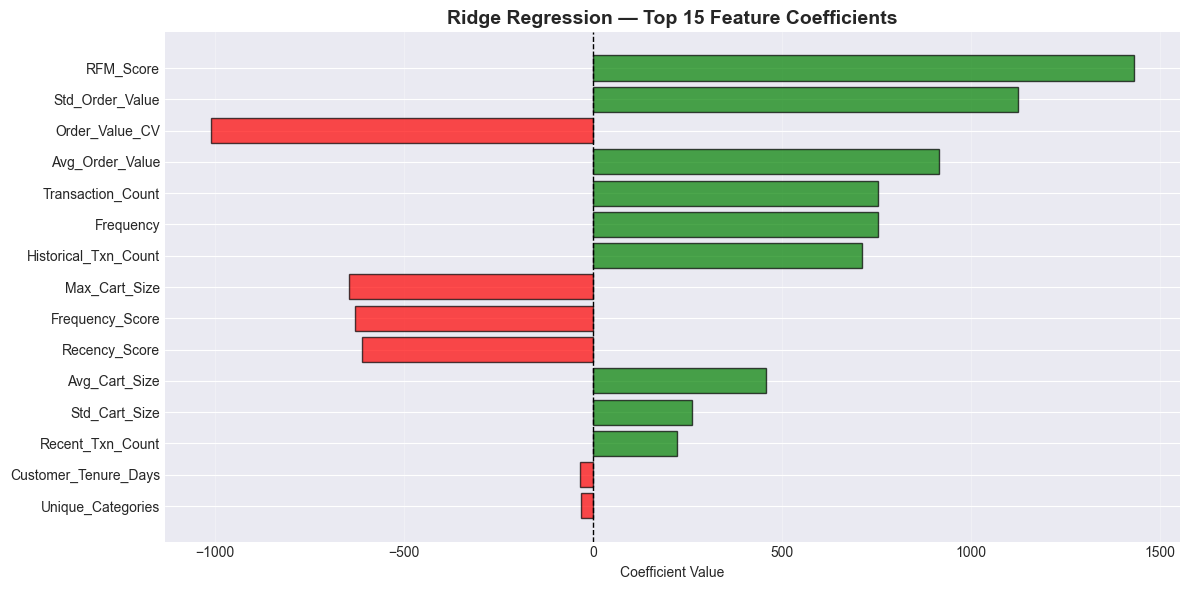

In [26]:
# Ridge coefficients are signed: positive means the feature increases predicted CLV,
# negative means it decreases it. I sort by absolute magnitude to find the most influential inputs.
ridge_coef = pd.DataFrame({
    'Feature':     X_train.columns,
    'Coefficient': ridge_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False).head(15)

colors = ['red' if c < 0 else 'green' for c in ridge_coef['Coefficient']]

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(ridge_coef['Feature'], ridge_coef['Coefficient'], color=colors, alpha=0.7, edgecolor='black')
ax.set_xlabel('Coefficient Value')
ax.set_title('Ridge Regression — Top 15 Feature Coefficients', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/clv_ridge_coefficients.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 12: SHAP Explainability (Best Model)

SHAP (SHapley Additive exPlanations) assigns each feature a contribution value for every individual prediction. This goes beyond global importance plots — it shows not just which features matter on average but also whether high or low values of a feature push CLV up or down. I run SHAP on the best model (determined by R² in the comparison step).

In [27]:
# Map the winning model name back to the fitted model object
model_mapping = {
    'Ridge Regression': ridge_model,
    'Random Forest':    rf_model,
    'XGBoost':          xgb_model,
    'LightGBM':         lgb_model,
}
best_model = model_mapping[best_model_name]
print(f"Running SHAP on: {best_model_name}")

Running SHAP on: Random Forest


In [28]:
# I subsample the test set to 1 000 rows to keep SHAP computation time manageable.
# TreeExplainer uses exact Shapley values for tree-based models; LinearExplainer uses
# the closed-form solution for linear models — both are exact, not approximate.
sample_size = min(1000, len(X_test_scaled))
X_test_sample = X_test_scaled.sample(n=sample_size, random_state=RANDOM_STATE)

if best_model_name == 'Ridge Regression':
    explainer  = shap.LinearExplainer(best_model, X_train_scaled)
else:
    explainer  = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(X_test_sample)
print(f"SHAP values computed for {sample_size} test customers")

SHAP values computed for 1000 test customers


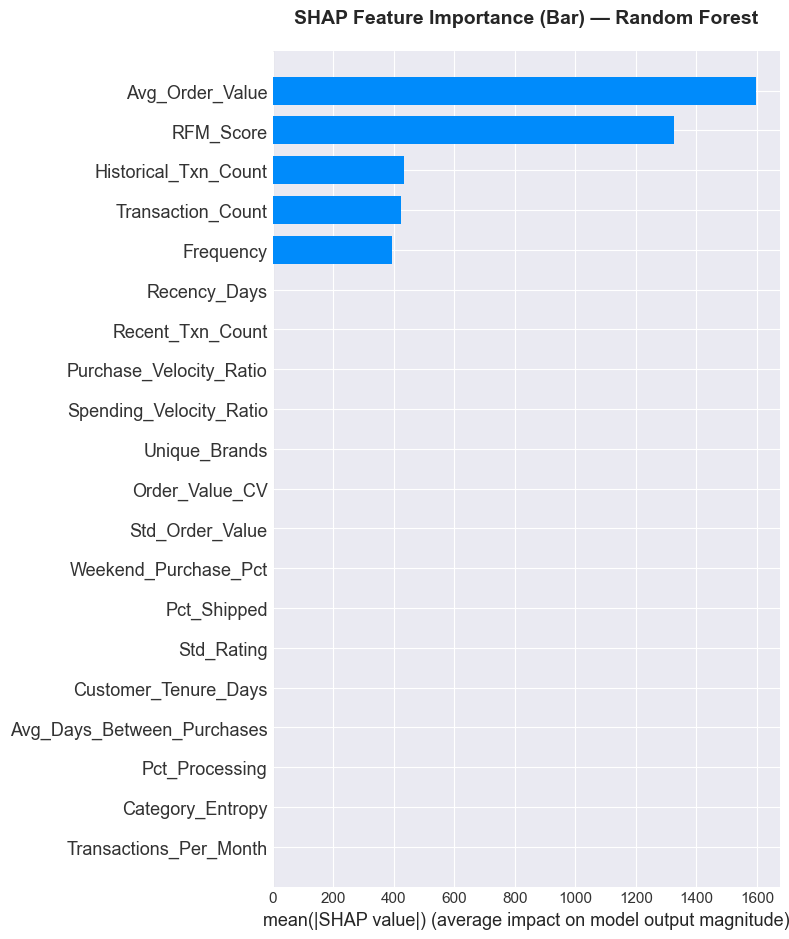

In [29]:
# Bar plot of mean absolute SHAP value per feature — global feature importance.
# This is more trustworthy than tree-based importance because it measures actual
# prediction attribution rather than impurity reduction during training.
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_sample, plot_type='bar', show=False, max_display=20)
plt.title(f'SHAP Feature Importance (Bar) — {best_model_name}', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../reports/clv_shap_bar.png', dpi=300, bbox_inches='tight')
plt.show()

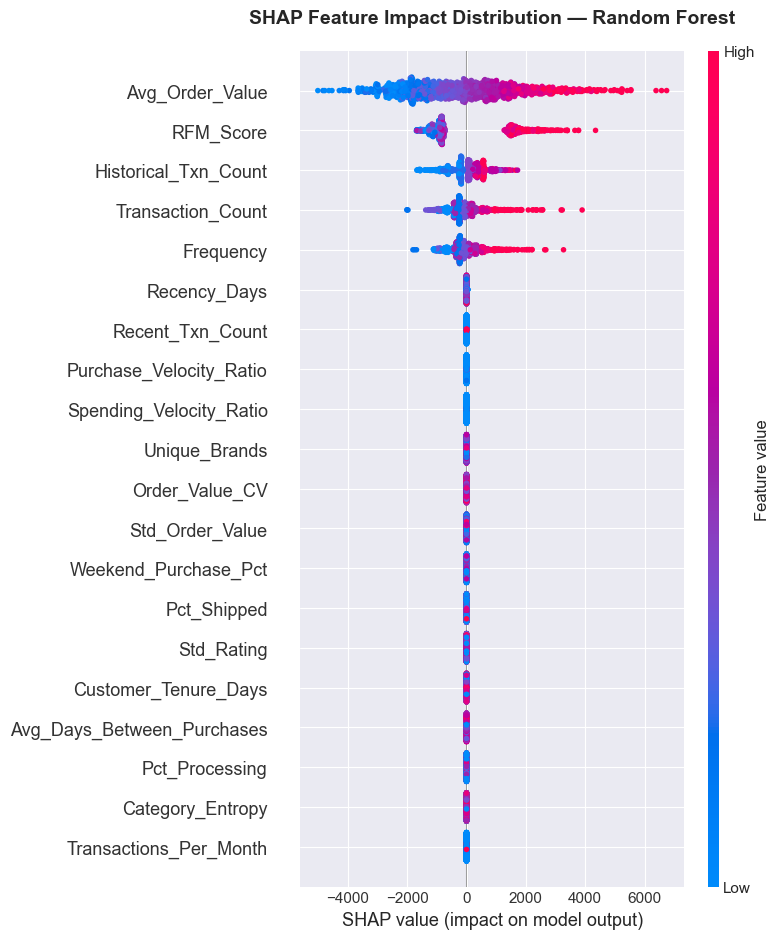

In [30]:
# Beeswarm (dot) plot — each dot is one customer's SHAP value for one feature.
# Colour shows whether the feature value is high (red) or low (blue).
# This reveals directionality: do high-frequency customers always get higher CLV predictions?
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_sample, show=False, max_display=20)
plt.title(f'SHAP Feature Impact Distribution — {best_model_name}', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../reports/clv_shap_beeswarm.png', dpi=300, bbox_inches='tight')
plt.show()

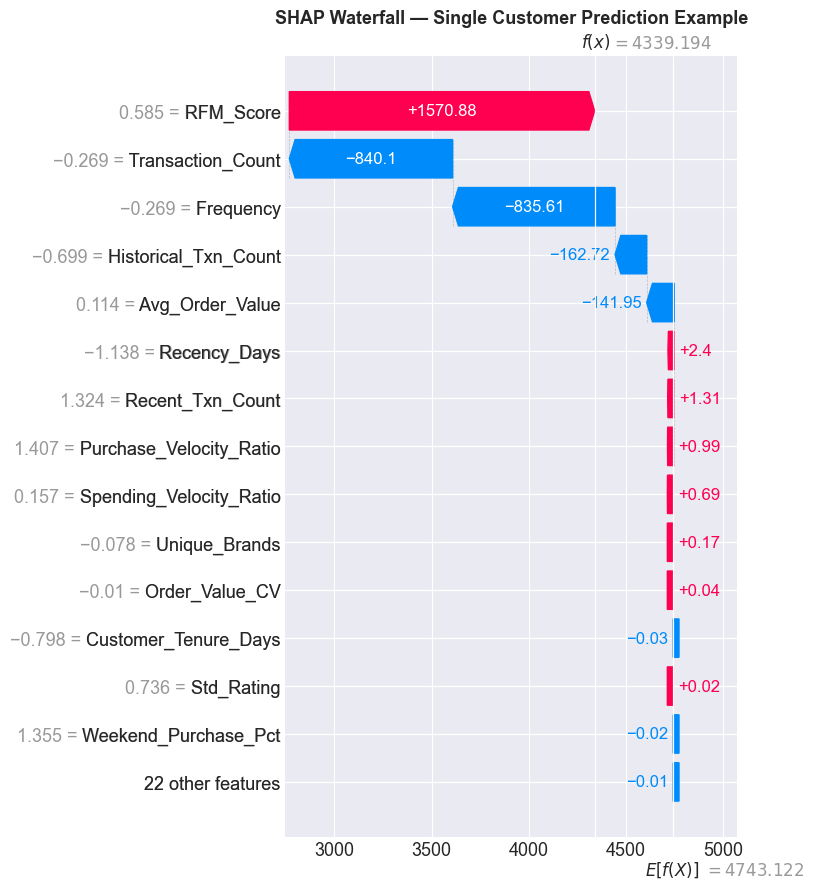

In [31]:
# Waterfall plot for a single customer prediction.
# This shows how the model arrived at one specific CLV estimate by stacking
# positive and negative feature contributions on top of the baseline expected value.
# Useful for explaining individual predictions to a business stakeholder.
shap.waterfall_plot(shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=X_test_sample.iloc[0],
    feature_names=X_test_sample.columns.tolist()
), max_display=15, show=False)

plt.title('SHAP Waterfall — Single Customer Prediction Example', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/clv_shap_waterfall.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 13: Save Models, Scaler, and Metadata

In [32]:
# Save all four trained models with consistent, version-free filenames.
# Version information is stored in the accompanying metadata JSON so I can
# always trace when a model was trained without encoding timestamps in filenames.
models_to_save = [
    ('clv_ridge.pkl',  ridge_model),
    ('clv_rf.pkl',     rf_model),
    ('clv_xgboost.pkl', xgb_model),
    ('clv_lightgbm.pkl', lgb_model),
]

for filename, model in models_to_save:
    joblib.dump(model, MODEL_DIR + filename)
    print(f"Saved: {MODEL_DIR + filename}")

Saved: ../artifacts/models/clv_ridge.pkl
Saved: ../artifacts/models/clv_rf.pkl
Saved: ../artifacts/models/clv_xgboost.pkl
Saved: ../artifacts/models/clv_lightgbm.pkl


In [33]:
# The scaler must be loaded alongside any model at inference time so
# new customer features are standardised with the exact same mean and variance
joblib.dump(scaler, SCALER_DIR + 'clv_scaler.pkl')
print(f"Scaler saved: {SCALER_DIR}clv_scaler.pkl")

Scaler saved: ../artifacts/scalers/clv_scaler.pkl


In [34]:
# Save the exact list of feature column names the models expect.
# This file is read by the FastAPI serving layer to validate incoming request payloads.
with open(MODEL_DIR + 'clv_features.json', 'w') as f:
    json.dump({'features': feature_cols, 'n_features': len(feature_cols)}, f, indent=4)
print(f"Feature list saved: {MODEL_DIR}clv_features.json")

Feature list saved: ../artifacts/models/clv_features.json


In [35]:
# Save per-model metadata JSON files.
# These record the training dataset, feature count, split sizes, and test metrics
# so any future reader can understand exactly what conditions produced this model.
metadata_map = [
    ('clv_ridge_metadata.json',    'ridge_regression', ridge_test_metrics),
    ('clv_rf_metadata.json',       'random_forest',    rf_test_metrics),
    ('clv_xgboost_metadata.json',  'xgboost',          xgb_test_metrics),
    ('clv_lightgbm_metadata.json', 'lightgbm',         lgb_test_metrics),
]

for filename, model_name, metrics in metadata_map:
    metadata = {
        'model_name':      model_name,
        'training_date':   datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'dataset_path':    DATA_PATH,
        'n_train':         int(len(X_train)),
        'n_test':          int(len(X_test)),
        'n_features':      int(len(feature_cols)),
        'test_size':       float(TEST_SIZE),
        'random_state':    int(RANDOM_STATE),
        'metrics': {
            'rmse': round(metrics['RMSE'], 4),
            'mae':  round(metrics['MAE'],  4),
            'r2':   round(metrics['R2'],   4),
            'mape': round(metrics['MAPE'], 4),
        }
    }
    with open(MODEL_DIR + filename, 'w') as f:
        json.dump(metadata, f, indent=4)
    print(f"Metadata saved: {MODEL_DIR + filename}")

Metadata saved: ../artifacts/models/clv_ridge_metadata.json
Metadata saved: ../artifacts/models/clv_rf_metadata.json
Metadata saved: ../artifacts/models/clv_xgboost_metadata.json
Metadata saved: ../artifacts/models/clv_lightgbm_metadata.json


In [36]:
# Save the model comparison table so the FastAPI deployment summary endpoint
# can serve this data without re-running the notebook
comparison_df.to_csv(MODEL_DIR + 'clv_model_comparison.csv', index=False)
print(f"Comparison table saved: {MODEL_DIR}clv_model_comparison.csv")

Comparison table saved: ../artifacts/models/clv_model_comparison.csv


## Summary

In [37]:
# Print a compact deployment summary: which model won and what performance it achieved
print(f"Best model:     {best_model_name}")
print(f"  R2:           {comparison_df.iloc[0]['R2']:.4f}")
print(f"  RMSE:         ${comparison_df.iloc[0]['RMSE']:.2f}")
print(f"  MAE:          ${comparison_df.iloc[0]['MAE']:.2f}")
print(f"  MAPE:         {comparison_df.iloc[0]['MAPE']:.2f}%")
print(f"\nTraining rows:  {len(X_train):,}")
print(f"Test rows:      {len(X_test):,}")
print(f"Features used:  {len(feature_cols)}")
print(f"CLV range:      ${y.min():.2f} — ${y.max():.2f}  (mean ${y.mean():.2f})")

Best model:     Random Forest
  R2:           0.9996
  RMSE:         $63.37
  MAE:          $6.02
  MAPE:         0.11%

Training rows:  69,392
Test rows:      17,348
Features used:  36
CLV range:      $10.30 — $29241.78  (mean $4746.48)


## Summary

In this notebook I built a complete CLV regression pipeline using four algorithms and identified the best model for production deployment.

### What I did

**Data preparation**
- Loaded `customer_features_enriched.csv` (one row per customer, 54 features)
- Removed four leakage columns that are direct components of the CLV target
- Dropped identifier, date, and text columns to keep the feature matrix fully numeric
- Stratified the 80/20 train-test split by LTV decile to preserve the target distribution

**Modelling**
- Scaled features with `StandardScaler` fitted on training data only
- Trained Ridge (linear baseline), Random Forest, XGBoost, and LightGBM
- Evaluated all four models on RMSE, MAE, R², and MAPE on the held-out test set
- Generated feature importance plots for all models and SHAP attribution for the best model

**Artefact export**
- Saved all four models as `.pkl` files with consistent names
- Saved the `StandardScaler` for use at inference time
- Saved per-model metadata JSON files recording training conditions and metrics
- Saved the model comparison table and key visualisations to `reports/`

### Saved artefacts

```
artifacts/models/
    clv_ridge.pkl              clv_ridge_metadata.json
    clv_rf.pkl                 clv_rf_metadata.json
    clv_xgboost.pkl            clv_xgboost_metadata.json
    clv_lightgbm.pkl           clv_lightgbm_metadata.json
    clv_features.json
    clv_model_comparison.csv

artifacts/scalers/
    clv_scaler.pkl

reports/
    clv_target_distribution.png
    clv_model_comparison.png
    clv_predicted_vs_actual.png
    clv_feature_importance_trees.png
    clv_ridge_coefficients.png
    clv_shap_bar.png
    clv_shap_beeswarm.png
    clv_shap_waterfall.png
```